In [1]:
import sys, os
import matplotlib.pyplot as plt
from skimage import data
import cv2

# Add parent directory to the Python path
notebook_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(notebook_dir, '..'))
sys.path.append(parent_dir)

from impro_tools.PatternMaker import PatternMaker

In [2]:
# Define the pattern maker
pm = PatternMaker()

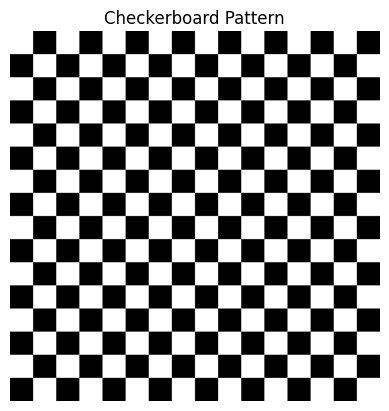

In [3]:
# Create and display a checkerboard pattern
checkboard = pm.create_checkerboard()
plt.imshow(checkboard, cmap='gray')
plt.title('Checkerboard Pattern')
plt.axis('off')
plt.show()

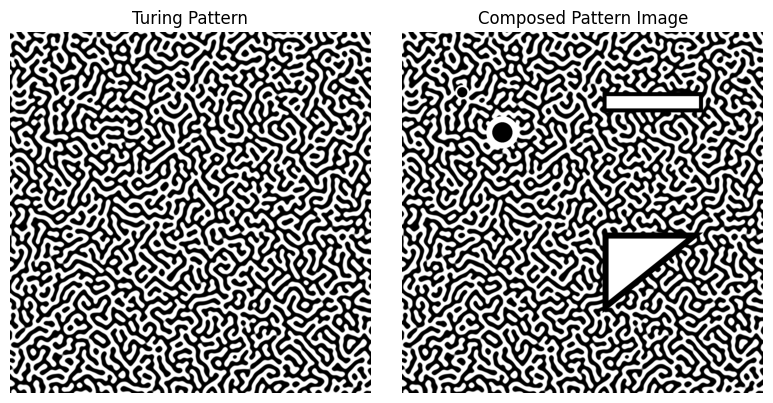

In [4]:
# Create a Turing pattern and compose it with shapes
img_width, img_height = 6, 6    # image size, in inches
dpi = 300                       # image resolution, in dots per inch
img_width = img_width*dpi       # image width, in pixels
img_height = img_height*dpi     # image height, in pixels
size = (img_height, img_width)

# Create Turing pattern image
turing_img = pm.create_turing_pattern(size, rep=10, radius=dpi/30, sharpen_percent=500)

# Compose with different shapes
# 1) Draw circles
composed_img = turing_img.copy()
pm.draw_circle(composed_img, 300, 300, fill='black', outline='white', circle_diameter=50, line_width=10)
pm.draw_circle(composed_img, 500, 500, fill='black', outline='white', circle_diameter=100, line_width=30)
# 2) Draw rectangle
rect = (1000, 300, 1500, 400)
pm.draw_rect(composed_img, rect, fill='White', outline='black', line_width=20)
# 3) Draw triangle
rect = (1000, 1000, 1500, 1400)
pm.draw_triangle(composed_img, rect, fill='White', outline='black',line_width=30)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(turing_img, cmap='gray', interpolation=None)
plt.title('Turing Pattern')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(composed_img, cmap='gray', interpolation=None)
plt.title('Composed Pattern Image')
plt.axis('off')
plt.tight_layout()
plt.show()

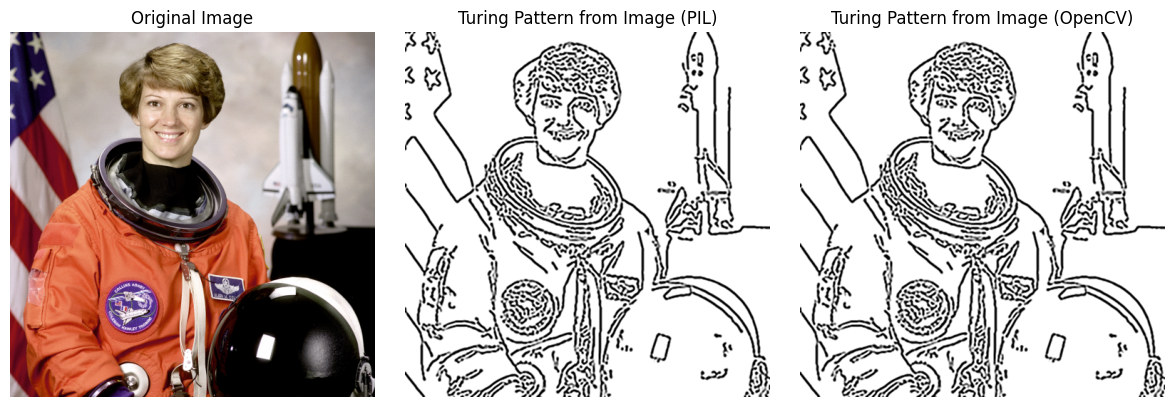

In [5]:
# Try the turing filter on an image
img = data.astronaut()

turing_img     = pm.create_turing_image(img, rep=10, radius=1, sharpen_percent=200, canny_th=(100,200))
turing_img_cv2 = pm.create_turing_image(img, rep=10, radius=1, sharpen_percent=200, canny_th=(100,200), use_cv2=False, as_PIL=False)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(turing_img, cmap='gray')
plt.title('Turing Pattern from Image (PIL)')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(turing_img_cv2, cmap='gray')
plt.title('Turing Pattern from Image (OpenCV)')
plt.axis('off')
plt.tight_layout()
plt.show()  

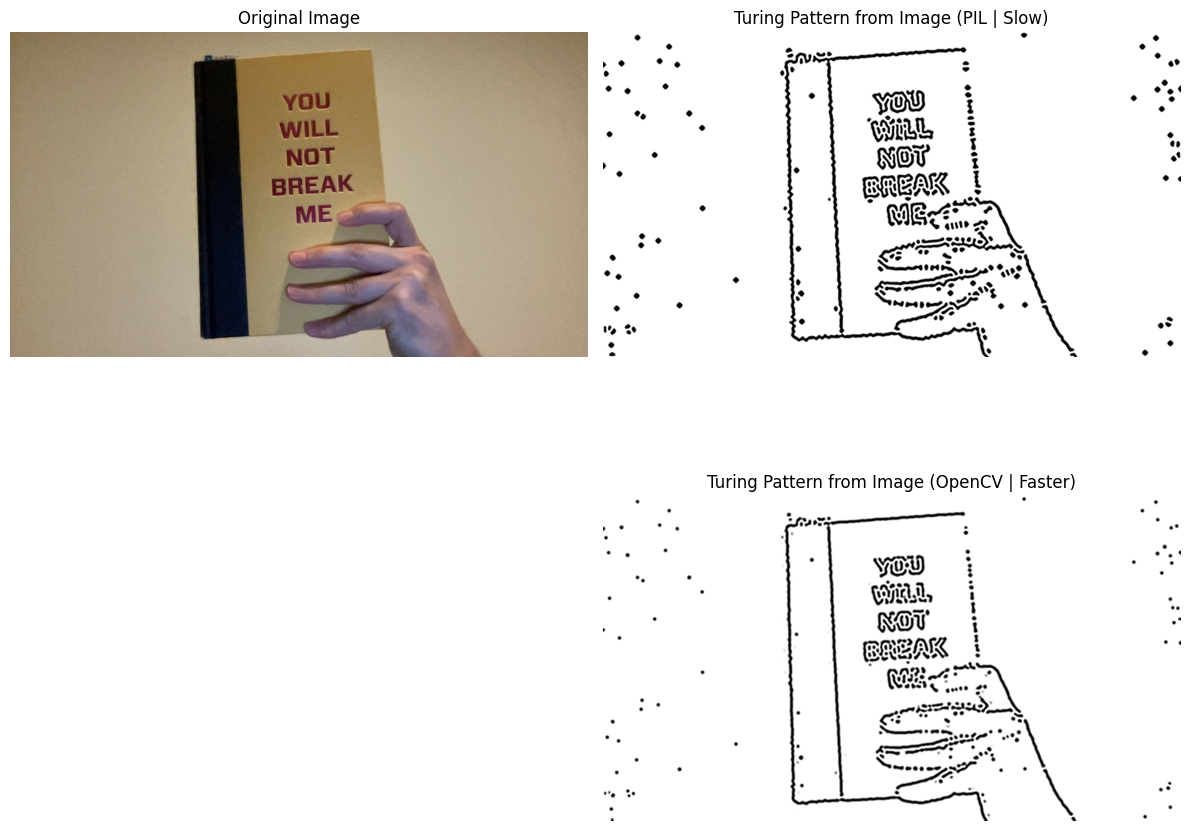

In [6]:
# Compare the two methods:
#   1) PIL:     Sharper     | Slower
#   2) OpenCV   Less sharp  | Faster

# Image taken with live video
img = cv2.imread("assets/book_img.png", cv2.IMREAD_COLOR)[:,:,::-1]

turing_img_pil = pm.create_turing_image(img, rep=20, radius=2, sharpen_percent=300, canny_th=(100,100))
turing_img_cv2 = pm.create_turing_image(img, rep=20, radius=2, sharpen_percent=300, canny_th=(100,100), use_cv2=True, as_PIL=False)
plt.figure(figsize=(12,10))
plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.subplot(2,2,2)
plt.imshow(turing_img_pil, cmap='gray')
plt.title('Turing Pattern from Image (PIL | Slow)')
plt.axis('off')
plt.subplot(2,2,4)
plt.imshow(turing_img_cv2, cmap='gray')
plt.title('Turing Pattern from Image (OpenCV | Faster)')
plt.axis('off')
plt.tight_layout()
plt.show()